# GEOG5990M Final Assignment (Template)

Student ID number: 202013686

In [ ]:
# read in required packages
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pyproj
import seaborn as sns
from scipy import stats
from shapely.geometry import Point

# **LSOA**

In [ ]:
uk_lsoa=gpd.read_file('/content/LSOA_2021_EW_BGC_V5.shp')

**Data Description**

In [ ]:
#check the variables of losa
uk_lsoa.columns

Index(['LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG',
       'GlobalID', 'geometry'],
      dtype='object')

In [ ]:
#check the 5 top rows
uk_lsoa.head(5)

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01000001,City of London 001A,None,532123,181632,51.5182,-0.097150,86214465-5cf4-4e8f-9492-3667471c42d6,"POLYGON ((532105.312 182010.574, 532162.491 18..."
1,E01000002,City of London 001B,None,532480,181715,51.5188,-0.091970,cd40c491-6567-405f-8c18-426e17b356ce,"POLYGON ((532634.497 181926.016, 532619.141 18..."
2,E01000003,City of London 001C,None,532239,182033,51.5217,-0.095330,7fd27aaf-d858-4e46-9099-92b43f66b948,"POLYGON ((532135.138 182198.131, 532158.25 182..."
3,E01000005,City of London 001E,None,533581,181283,51.5147,-0.076280,7e76a16a-028f-4f49-84b5-6e5a67322f3c,"POLYGON ((533808.018 180767.774, 533649.037 18..."
4,E01000006,Barking and Dagenham 016A,None,544994,184274,51.5387,0.089317,25ab047e-6fcf-4f76-9176-e92e44c0e097,"POLYGON ((545122.049 184314.931, 545271.849 18..."


In [ ]:
#extract the lsoa of leeds  from the whole UK
leeds_lsoa = uk_lsoa[uk_lsoa['LSOA21NM'].str.startswith('Leeds')]

In [ ]:
leeds_lsoa.shape

(488, 9)

There are 488 rows and 9 columns in this dataset.

In [ ]:
# check the 5 top rows of new data
leeds_lsoa.head(5)

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
10719,E01011264,Leeds 011A,None,420937,441836,53.8723,-1.68306,64fb7b6a-27ee-4fa8-a1ca-4afde43ea40d,"POLYGON ((421354.761 442327.389, 421423.688 44..."
10720,E01011265,Leeds 009A,None,418988,441951,53.8734,-1.71270,fbdef384-ef8d-4255-b68e-6b2aed79304d,"POLYGON ((418598.68 442761.477, 418637.555 442..."
10721,E01011266,Leeds 008A,None,417489,442615,53.8795,-1.73546,ba94fe93-06c4-4c65-b854-97028172e051,"POLYGON ((418337 441566, 418335.674 441589.328..."
10722,E01011267,Leeds 009B,None,419641,442025,53.8741,-1.70276,8e52c811-179b-487e-8f4c-d4b1e89f257a,"POLYGON ((419594.91 442295.179, 419657.752 442..."
10723,E01011268,Leeds 010A,None,420224,441935,53.8732,-1.69390,121a6a6f-257b-4798-8180-928ca868ed40,"POLYGON ((420308.893 442013.704, 420322.898 44..."


In [ ]:
#count the number of null values in each column of the DataFrame
leeds_lsoa.isnull().sum()

,0
LSOA21CD,0
LSOA21NM,0
LSOA21NMW,488
BNG_E,0
BNG_N,0
LAT,0
LONG,0
GlobalID,0
geometry,0


In [ ]:
#drop the unwanted column
leeds_lsoa_cleaned=leeds_lsoa.drop(columns=['LSOA21NMW'])
leeds_lsoa=leeds_lsoa_cleaned

In [ ]:
#check if the column is dropped successfully
leeds_lsoa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 488 entries, 10719 to 33048
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LSOA21CD  488 non-null    object  
 1   LSOA21NM  488 non-null    object  
 2   BNG_E     488 non-null    int64   
 3   BNG_N     488 non-null    int64   
 4   LAT       488 non-null    float64 
 5   LONG      488 non-null    float64 
 6   GlobalID  488 non-null    object  
 7   geometry  488 non-null    geometry
dtypes: float64(2), geometry(1), int64(2), object(3)
memory usage: 50.5+ KB


LSOA codes and names store textual or identifier information, which are not used to calculate. Consequently, the type of these code and names are object. Coordinates and latitude/longitude store numerical values used in calculations. The geometry column stores spatial information.

In [ ]:
leeds_lsoa.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

Check the coordinate reference system(CRS) of leeds_lsoa to ensure consistency before performing a spatial join.





# **Community Service**

In [ ]:
service=pd.read_csv('/content/Community with postcodes Apr_2020-with-coordinates.csv')

In [ ]:
service.head(5)

,UPRN,ORGANISATION,Secondary Name,Secondary Number,Primary Name,Primary Number,Street Name,Locality,Town,Postal Town,Latitude,Longitude,X_COORD,Y_COORD,LON_WGS84,LAT_WGS84,BLPU_CLASS,BLPU_CLASS_DESC,LPI_LEVEL
0,72670282,Yorkshire Ambulance Service NHS Trust,Ambulance Service Building Rear Of,NaN,NaN,15,Morris Lane,Kirkstall,Leeds,Leeds,53.81716,-1.59969,426453.0,435728.0,-1.599694,53.817165,CX03,"Commercial, Emergency and Rescue Service, Ambu...",Ground
1,72137688,NaN,NaN,NaN,St Stephens C Of E Primary School,NaN,Morris Lane,Kirkstall,Leeds,Leeds,53.81909,-1.60084,426376.0,435942.0,-1.600845,53.819092,CE03,"Commercial, Education, Primary, Junior, Infant...",NaN
2,72137622,Kirkstall Health Centre,NaN,NaN,NaN,15,Morris Lane,Kirkstall,Leeds,Leeds,53.81716,-1.59969,426453.0,435728.0,-1.599694,53.817165,CM02,"Commercial, Medical, GP Surgeries and Clinics",NaN
3,72138490,Cookridge Village Association,NaN,NaN,Community Centre,NaN,Moseley Wood Lane,Cookridge,Leeds,Leeds,53.85956,-1.61843,425194.0,440439.0,-1.618432,53.859566,CC04,"Commercial, Community Services, Public and Vil...",Ground
4,72138792,NaN,NaN,NaN,Bright Beginnings Childcare Centre,NaN,Mount Preston Street,Woodhouse,Leeds,Leeds,53.80563,-1.55977,429089.0,434461.0,-1.559777,53.805637,CE02,"Commercial, Education, Nursery/Creche",NaN


In [ ]:
service.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1452 entries, 0 to 1451
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   UPRN              1452 non-null   int64  
 1   ORGANISATION      626 non-null    object 
 2   Secondary Name    230 non-null    object 
 3   Secondary Number  13 non-null     object 
 4   Primary Name      1116 non-null   object 
 5   Primary Number    475 non-null    object 
 6   Street Name       1452 non-null   object 
 7   Locality          1230 non-null   object 
 8   Town              1452 non-null   object 
 9   Postal Town       1279 non-null   object 
 10  Latitude          1383 non-null   float64
 11  Longitude         1383 non-null   float64
 12  X_COORD           1386 non-null   float64
 13  Y_COORD           1386 non-null   float64
 14  LON_WGS84         1377 non-null   float64
 15  LAT_WGS84         1377 non-null   float64
 16  BLPU_CLASS        1452 non-null   object 


This dataset mainly indicate some attributes of service community. Therefore, many types of these variables are object.

In [ ]:
service.isnull().sum()

,0
UPRN,0
ORGANISATION,826
Secondary Name,1222
Secondary Number,1439
Primary Name,336
Primary Number,977
Street Name,0
Locality,222
Town,0
Postal Town,173


This dataset contains detailed information on location and identity, with missing values at an acceptable level for analysis.

In [ ]:
service.shape

(1452, 19)

In [ ]:
#check the variables of service community
service.columns


Index(['UPRN', 'ORGANISATION', 'Secondary Name', 'Secondary Number',
       'Primary Name', 'Primary Number', 'Street Name', 'Locality', 'Town',
       'Postal Town', 'Latitude', 'Longitude', 'X_COORD', 'Y_COORD',
       'LON_WGS84', 'LAT_WGS84', 'BLPU_CLASS', 'BLPU_CLASS_DESC', 'LPI_LEVEL'],
      dtype='object')

In [ ]:
service = service.drop(columns=['Latitude','Longitude','X_COORD','Y_COORD'])

To avoid confusion between coordinate systems, only WGS84 coordinates are retained.

In [ ]:
service = service.dropna(subset=['LAT_WGS84','LON_WGS84'])

Remove rows containing missing values to prevent errors during downstream spatial operations, thereby ensuring the overall quality of the dataset.

In [ ]:
#drop the useless columns
service = service.drop(columns=['ORGANISATION','Secondary Name','Secondary Number','Primary Name','Primary Number','Locality','Postal Town'])


In the subsequent analysis, our research focuses on the quantity of community service locations within the LSOA output areas, and the specific types of these service points are not required for the study. Therefore, we first remove the columns that represent the detailed attributes of the service points.



In [ ]:
#change the type of service to gpd for spatial join
service_gdf=gpd.GeoDataFrame(service,geometry=gpd.points_from_xy(service['LON_WGS84'],service['LAT_WGS84']),crs='EPSG:4326')
#change the crs from 4326 to 27700
service_gdf = service_gdf.to_crs('EPSG:27700')

<Axes: >

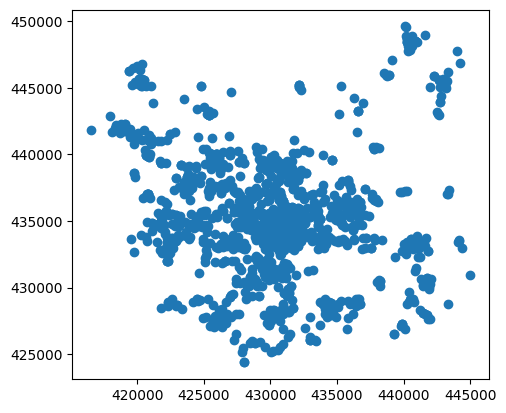

In [ ]:
#creat a plot to learn from spatial distribution
service_gdf.plot()

Spatial Join

In [ ]:
service_leeds=gpd.sjoin(service_gdf,leeds_lsoa[['LSOA21CD','geometry']],how='inner',predicate='within')

In [ ]:
#calculate the points of service in leeds
print('Points in leeds:', len(service_leeds))

Points in leeds: 1377


In [ ]:
service_leeds.explore()

In [ ]:
#group data by area code
grouped_data = service_leeds.groupby('LSOA21CD')
#calculate the number of service points for each LSOA area
service_count = grouped_data.size()
#convert to dataframe and rename count column
leeds_counts = service_count.reset_index(name='service_count')

In [ ]:
#view the first 5 rows of the result
leeds_counts.head()

,LSOA21CD,service_count
0,E01011264,1
1,E01011265,8
2,E01011266,1
3,E01011267,4
4,E01011268,2


In [ ]:
#merge the service point count statistics with the original leeds LSOA geodata
leeds_lsoa_service=leeds_lsoa.merge(leeds_counts,on='LSOA21CD',how='left')
#use 0 to fill NAN
leeds_lsoa_service['service_count'] = (leeds_lsoa_service['service_count'].fillna(0).astype(int))

Left-joins service point counts to Leeds LSOA data, retains all areas, fills NaN with 0 for valid, complete spatial analysis.

In [ ]:
leeds_lsoa_service.head(5)

,LSOA21CD,LSOA21NM,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,service_count
0,E01011264,Leeds 011A,420937,441836,53.8723,-1.68306,64fb7b6a-27ee-4fa8-a1ca-4afde43ea40d,"POLYGON ((421354.761 442327.389, 421423.688 44...",1
1,E01011265,Leeds 009A,418988,441951,53.8734,-1.71270,fbdef384-ef8d-4255-b68e-6b2aed79304d,"POLYGON ((418598.68 442761.477, 418637.555 442...",8
2,E01011266,Leeds 008A,417489,442615,53.8795,-1.73546,ba94fe93-06c4-4c65-b854-97028172e051,"POLYGON ((418337 441566, 418335.674 441589.328...",1
3,E01011267,Leeds 009B,419641,442025,53.8741,-1.70276,8e52c811-179b-487e-8f4c-d4b1e89f257a,"POLYGON ((419594.91 442295.179, 419657.752 442...",4
4,E01011268,Leeds 010A,420224,441935,53.8732,-1.69390,121a6a6f-257b-4798-8180-928ca868ed40,"POLYGON ((420308.893 442013.704, 420322.898 44...",2


In [ ]:
leeds_lsoa_service.describe()

,BNG_E,BNG_N,LAT,LONG,service_count
count,488.000000,488.000000,488.000000,488.000000,488.000000
mean,429745.625000,434948.334016,53.809962,-1.549772,2.821721
std,5765.760679,4842.130100,0.043536,0.087553,2.870043
min,415777.000000,424017.000000,53.711800,-1.761520,0.000000
25%,425662.500000,432060.750000,53.784175,-1.611582,1.000000
50%,429497.000000,434871.000000,53.809400,-1.553590,2.000000
75%,433151.750000,437635.000000,53.834150,-1.498177,4.000000
max,444141.000000,449492.000000,53.940000,-1.330510,27.000000


In [ ]:
#check the mumber of 0 with a reasonable range
(leeds_lsoa_service['service_count'] == 0).sum()

np.int64(77)

In [ ]:
#drop the unwanted columns
leeds_lsoa_service_cleaned=leeds_lsoa_service.drop(columns=['GlobalID','BNG_E','BNG_N','LAT','LONG'])
leeds_lsoa_service=leeds_lsoa_service_cleaned

In [ ]:
leeds_lsoa_service.head()

,LSOA21CD,LSOA21NM,geometry,service_count
0,E01011264,Leeds 011A,"POLYGON ((421354.761 442327.389, 421423.688 44...",1
1,E01011265,Leeds 009A,"POLYGON ((418598.68 442761.477, 418637.555 442...",8
2,E01011266,Leeds 008A,"POLYGON ((418337 441566, 418335.674 441589.328...",1
3,E01011267,Leeds 009B,"POLYGON ((419594.91 442295.179, 419657.752 442...",4
4,E01011268,Leeds 010A,"POLYGON ((420308.893 442013.704, 420322.898 44...",2


**Data visualisation**

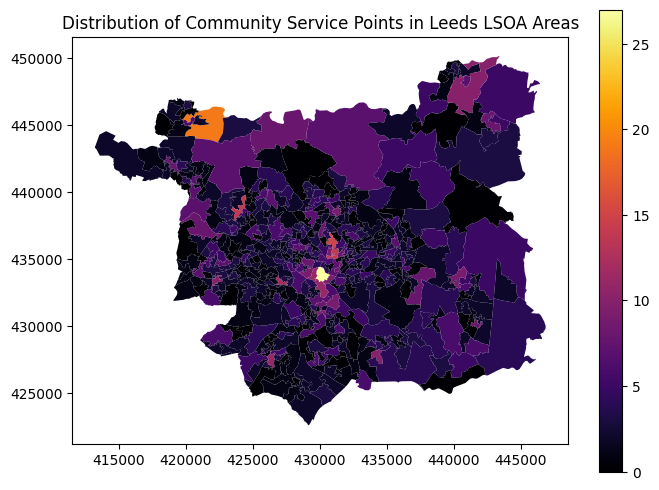

In [ ]:
#create a choropleth map
f,ax = plt.subplots(1,figsize=(8,6))
leeds_lsoa_service.plot(ax=ax,column ='service_count',legend=True,cmap='inferno')
plt.title('Distribution of Community Service Points in Leeds LSOA Areas')
plt.show()

The 'inferno' colormap was adopted in this visualization, as it presents a color gradient ranging from black-red to bright yellow. This color scheme effectively highlights that regions with a higher concentration of service points are predominantly located in the central area, while the majority of regions have a relatively low number of service points (mostly fewer than 10). Additionally, a title is included to provide a clear and immediate understanding of the map's subject matter.

# **Household Deprivation**

In [ ]:
deprivation=pd.read_csv('/content/household_deprivation.csv')

In [ ]:
deprivation.head(5)

,2021 super output area - lower layer,mnemonic,Total: All households,%,Household is not deprived in any dimension,%.1,Household is deprived in one dimension,%.2,Household is deprived in two dimensions,%.3,Household is deprived in three dimensions,%.4,Household is deprived in four dimensions,%.5
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Leeds 001A,E01011698,632.0,100.0,353.0,55.9,209.0,33.1,61.0,9.7,9.0,1.4,0.0,0.0
2,Leeds 001B,E01011699,575.0,100.0,361.0,62.8,173.0,30.1,40.0,7.0,1.0,0.2,0.0,0.0
3,Leeds 001C,E01011701,596.0,100.0,357.0,59.9,178.0,29.9,49.0,8.2,12.0,2.0,0.0,0.0
4,Leeds 001D,E01011702,664.0,100.0,459.0,69.1,167.0,25.2,33.0,5.0,4.0,0.6,1.0,0.2


In [ ]:
#rename the columns for simplification
deprivation_clean = deprivation.rename(columns={
    '2021 super output area - lower layer': 'LSOA21CD',
    'Total: All households': 'total_hh',
    'Household is not deprived in any dimension': 'dep_0',
    'Household is deprived in one dimension': 'dep_1',
    'Household is deprived in two dimensions': 'dep_2',
    'Household is deprived in three dimensions': 'dep_3',
    'Household is deprived in four dimensions': 'dep_4'}).copy()
deprivation=deprivation_clean

In [ ]:
deprivation.head(5)

,LSOA21CD,mnemonic,total_hh,%,dep_0,%.1,dep_1,%.2,dep_2,%.3,dep_3,%.4,dep_4,%.5
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Leeds 001A,E01011698,632.0,100.0,353.0,55.9,209.0,33.1,61.0,9.7,9.0,1.4,0.0,0.0
2,Leeds 001B,E01011699,575.0,100.0,361.0,62.8,173.0,30.1,40.0,7.0,1.0,0.2,0.0,0.0
3,Leeds 001C,E01011701,596.0,100.0,357.0,59.9,178.0,29.9,49.0,8.2,12.0,2.0,0.0,0.0
4,Leeds 001D,E01011702,664.0,100.0,459.0,69.1,167.0,25.2,33.0,5.0,4.0,0.6,1.0,0.2


This is an example block of mardown text I want to reference <a href="#ref1">[1]</a>. I might need to add some more citations <a href="#ref2">[2]</a><a href="#ref2">[3]</a>



Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

## References
<p><a href="add_url_here">[1]</a>Footnote citation goes here</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2]</a>GEOG5990M course materials</p>
<p><a href="add_url_here">[3]</a>Citation 3</p>